In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import yfinance as yf
data=yf.download("AAPL",start="2018-01-01",end="2026-02-04")


[*********************100%***********************]  1 of 1 completed


In [6]:
print(data.tail(10))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-21  247.418488  251.324836  244.950795  248.467509  54641700
2026-01-22  248.117844  250.765360  247.918018  248.967040  39708300
2026-01-23  247.808121  249.176850  244.451261  247.088808  41689000
2026-01-26  255.171234  256.320153  249.566478  251.244900  55969200
2026-01-27  258.028534  261.705117  257.968592  258.927717  49648300
2026-01-28  256.200287  258.618008  254.272083  257.409147  41288000
2026-01-29  258.038544  259.407258  254.172166  257.758807  67253000
2026-01-30  259.237427  261.655147  251.944233  254.931443  92443400
2026-02-02  269.757599  270.237131  258.967677  259.786917  73913400
2026-02-03  269.228088  271.625839  267.359811  268.948351  64394700


In [7]:
df=data.copy()

In [8]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Lag1,Lag2,Lag3
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2018-01-05,40.945271,41.031839,40.489024,40.580273,94640000,40.484337,40.297146,40.304180
2018-01-08,40.793190,41.087995,40.694918,40.793190,82271200,40.945271,40.484337,40.297146
2018-01-09,40.788494,40.959293,40.573239,40.839968,86336000,40.793190,40.945271,40.484337
2018-01-10,40.779137,40.781479,40.477313,40.514750,95839600,40.788494,40.793190,40.945271
2018-01-11,41.010780,41.059916,40.825943,40.849338,74670800,40.779137,40.788494,40.793190


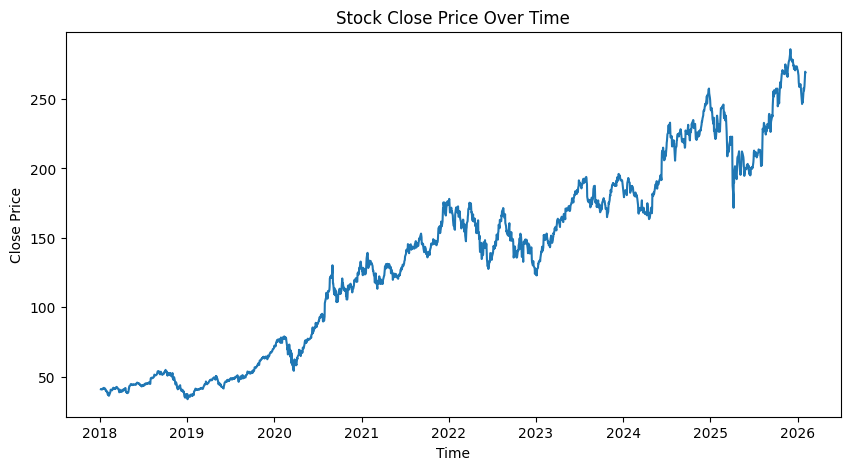

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Close Price Over Time")
plt.show()

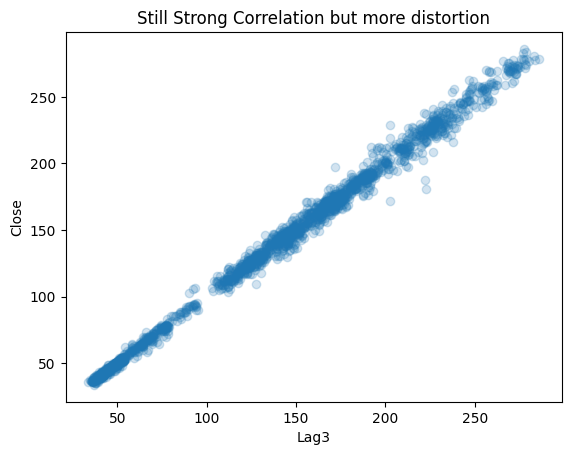

In [12]:
plt.scatter(df['Lag3'], df['Close'], alpha=0.2)
#alpha helps in managing the transparency level

plt.xlabel("Lag3")
plt.ylabel("Close")
plt.title("Still Strong Correlation but more distortion")
plt.show()

In [8]:
X=df[['Lag1','Lag2','Lag3']]
y=df['Close']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)



In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


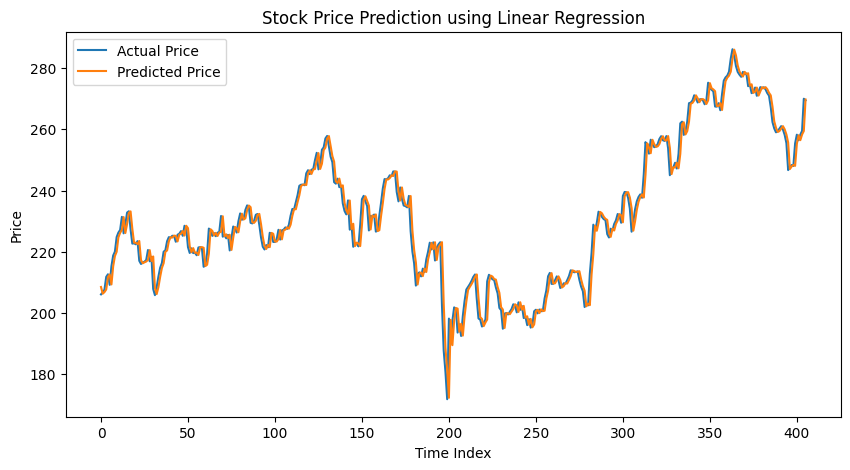

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.legend()
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()